# Simple Trading Rule

In [1]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
import matplotlib.pyplot as plt
%matplotlib inline

Configuring sim logging


Work up a minimum example of a trend following system

Let's get some data

We can get data from various places; however for now we're going to use
prepackaged 'legacy' data stored in csv files

In [2]:
data = csvFuturesSimData()
data

csvFuturesSimData object with 239 instruments

We get stuff out of data with methods

In [3]:
print(data.get_instrument_list())
print(data.get_raw_price("SGD").tail(5))

['FTSECHINAH', 'EU-MID', 'EU-DIV30', 'JP-REALESTATE', 'SMI', 'DJSTX-SMALL', 'LUMBER-new', 'EUROSTX200-LARGE', 'CAD5', 'PALLAD', 'GBPEUR', 'SP500_micro', 'BOVESPA', 'IRON', 'LEANHOG', 'GAS-LAST', 'US-STAPLES', 'ETHER-micro', 'VNKI', 'SOYBEAN', 'EU-DJ-UTIL', 'FTSEINDO', 'NZD', 'ETHANOL', 'GOLD', 'MSCIASIA', 'BB3M', 'EU-DJ-TECH', 'JPY_mini', 'EU-TECH', 'MIB', 'SMI-MID', 'GILT', 'BTP', 'EU-TRAVEL', 'MSCIWORLD', 'SWISSLEAD', 'SOYBEAN_mini', 'KRWUSD_mini', 'STEEL', 'HANGTECH', 'NASDAQ_micro', 'ROBUSTA', 'VIX_mini', 'CAD10', 'AEX', 'BBCOMM', 'NASDAQ', 'EU-HOUSE', 'HOUSE-US', 'NIKKEI400', 'RUSSELL', 'GASOILINE_micro', 'EURIBOR-ICE', 'CANOLA', 'EU-HEALTH', 'MSCIEAFA', 'SILVER', 'EUA', 'COPPER-micro', 'CHEESE', 'CAD_micro', 'EURCHF', 'GAS-PEN', 'MILKWET', 'CAC', 'CHF_micro', 'GASOIL', 'AUD', 'EU-CHEM', 'EU-DJ-OIL', 'BUND', 'EU-FOOD', 'US-MATERIAL', 'US10', 'KR10', 'GASOILINE_ICE', 'US-UTILS', 'EU-RETAIL', 'INR', 'OMX', 'CZK', 'COPPER', 'WHEY', 'CLP', 'SGD_mini', 'IG', 'TWD-mini', 'FEEDCOW', 'PLN

data can also behave in a dict like manner (though it's not a dict)

In [4]:
data['SP500']

index
1982-09-14 23:00:00     516.65
1982-09-15 23:00:00     517.15
1982-09-16 23:00:00     516.50
1982-09-17 23:00:00     515.60
1982-09-20 23:00:00     516.40
                        ...   
2023-08-30 17:00:00    4528.25
2023-08-30 18:00:00    4521.50
2023-08-30 19:00:00    4525.50
2023-08-30 20:00:00    4522.75
2023-08-30 23:00:00    4527.00
Name: price, Length: 34592, dtype: float64

In [5]:
data.keys()

['FTSECHINAH',
 'EU-MID',
 'EU-DIV30',
 'JP-REALESTATE',
 'SMI',
 'DJSTX-SMALL',
 'LUMBER-new',
 'EUROSTX200-LARGE',
 'CAD5',
 'PALLAD',
 'GBPEUR',
 'SP500_micro',
 'BOVESPA',
 'IRON',
 'LEANHOG',
 'GAS-LAST',
 'US-STAPLES',
 'ETHER-micro',
 'VNKI',
 'SOYBEAN',
 'EU-DJ-UTIL',
 'FTSEINDO',
 'NZD',
 'ETHANOL',
 'GOLD',
 'MSCIASIA',
 'BB3M',
 'EU-DJ-TECH',
 'JPY_mini',
 'EU-TECH',
 'MIB',
 'SMI-MID',
 'GILT',
 'BTP',
 'EU-TRAVEL',
 'MSCIWORLD',
 'SWISSLEAD',
 'SOYBEAN_mini',
 'KRWUSD_mini',
 'STEEL',
 'HANGTECH',
 'NASDAQ_micro',
 'ROBUSTA',
 'VIX_mini',
 'CAD10',
 'AEX',
 'BBCOMM',
 'NASDAQ',
 'EU-HOUSE',
 'HOUSE-US',
 'NIKKEI400',
 'RUSSELL',
 'GASOILINE_micro',
 'EURIBOR-ICE',
 'CANOLA',
 'EU-HEALTH',
 'MSCIEAFA',
 'SILVER',
 'EUA',
 'COPPER-micro',
 'CHEESE',
 'CAD_micro',
 'EURCHF',
 'GAS-PEN',
 'MILKWET',
 'CAC',
 'CHF_micro',
 'GASOIL',
 'AUD',
 'EU-CHEM',
 'EU-DJ-OIL',
 'BUND',
 'EU-FOOD',
 'US-MATERIAL',
 'US10',
 'KR10',
 'GASOILINE_ICE',
 'US-UTILS',
 'EU-RETAIL',
 'INR',
 'OMX

... however this will only access prices
(note these prices have already been backadjusted for rolls)

We have extra futures data here

In [6]:
data.get_instrument_raw_carry_data("SGD").tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2023-08-29 23:00:00,1.35450,1.35285,20230900,20231000
2023-08-30 06:00:00,1.35165,NaN,20230900,20231000
2023-08-30 12:00:00,1.35220,NaN,20230900,20231000
2023-08-30 15:00:00,1.34885,NaN,20230900,20231000
2023-08-30 23:00:00,1.35230,1.35070,20230900,20231000
2023-08-31 03:00:00,1.34905,1.34715,20230900,20231000


Technical note: csvFuturesSimData inherits from FuturesData which itself inherits from simData
The chain is 'data specific' <- 'asset class specific' <- 'generic'

Let's create a simple trading rule

No capping or scaling

In [7]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds
    Lfast, Lslow and vol_lookback

    """
    # price: This is the stitched price series
    # We can't use the price of the contract we're trading, or the volatility
    # will be jumpy
    # And we'll miss out on the rolldown. See
    # https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()

    if Lslow is None:
        Lslow = 4 * Lfast

    # We don't need to calculate the decay parameter, just use the span
    # directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma
    vol = robust_vol_calc(price.diff())
    return raw_ewmac / vol


Try it out

(this isn't properly scaled at this stage of course)


In [8]:
instrument_code = 'SGD'
price = data.daily_prices(instrument_code)
ewmac = calc_ewmac_forecast(price, 32, 128)
ewmac.columns = ['forecast']
ewmac.tail(5)

index
2023-08-25    1.543861
2023-08-28    1.695459
2023-08-29    1.817171
2023-08-30    1.894033
2023-08-31    1.904391
Freq: B, Name: price, dtype: float64

Text(0.5, 0, 'Time')

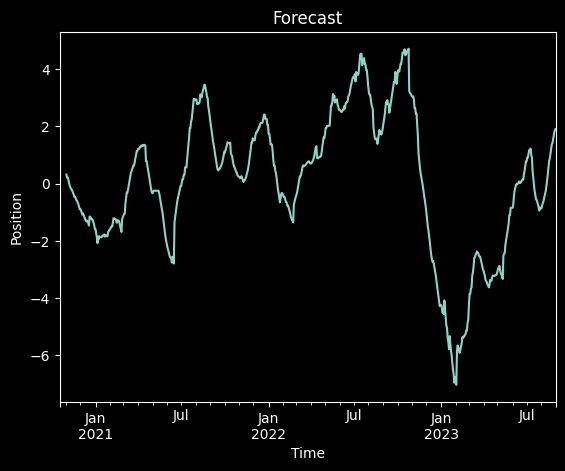

In [9]:
ewmac.plot();
plt.title('Forecast')
plt.ylabel('Position')
plt.xlabel('Time')


Did we make money?


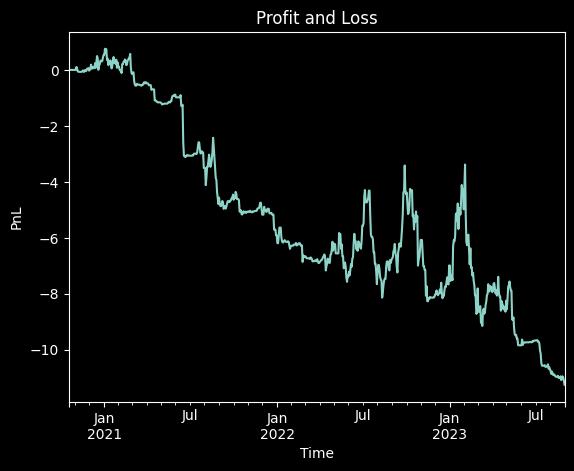

In [10]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast=ewmac, price = price)
account.curve().plot()
plt.title('Profit and Loss')
plt.ylabel('PnL')
plt.xlabel('Time')

In [11]:
account.percent.stats()

[[('min', '-1.77'),
  ('max', '1.215'),
  ('median', '0'),
  ('mean', '-0.01503'),
  ('std', '0.2538'),
  ('skew', '-1.13'),
  ('ann_mean', '-3.848'),
  ('ann_std', '4.061'),
  ('sharpe', '-0.9477'),
  ('sortino', '-0.9605'),
  ('avg_drawdown', '-5.871'),
  ('time_in_drawdown', '0.9733'),
  ('calmar', '-0.3203'),
  ('avg_return_to_drawdown', '-0.6554'),
  ('avg_loss', '-0.1886'),
  ('avg_gain', '0.1443'),
  ('gaintolossratio', '0.7648'),
  ('profitfactor', '0.8068'),
  ('hitrate', '0.5134'),
  ('t_stat', '-1.621'),
  ('p_value', '0.1054')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]